In [37]:
import matplotlib.pyplot as plt
import numpy as np


def load_mat_from_file(cur_file, step=0.0375):
    """
    step: 表示 相邻帧数据 步长
    """
    import h5py
    with h5py.File(cur_file, 'r') as f:
        pixels_array = f['d']['data'][:]
        pos = f['d']['pos'][:] * step
        ypos = f['d']['ypos'][:] * step
        posend = f['d']['posend'][:] * step
        yposend = f['d']['yposend'][:] * step
        
        pos_array = np.vstack((pos, ypos, posend, yposend)).T
    return pos_array, pixels_array

(600, 4) (600, 256, 101)


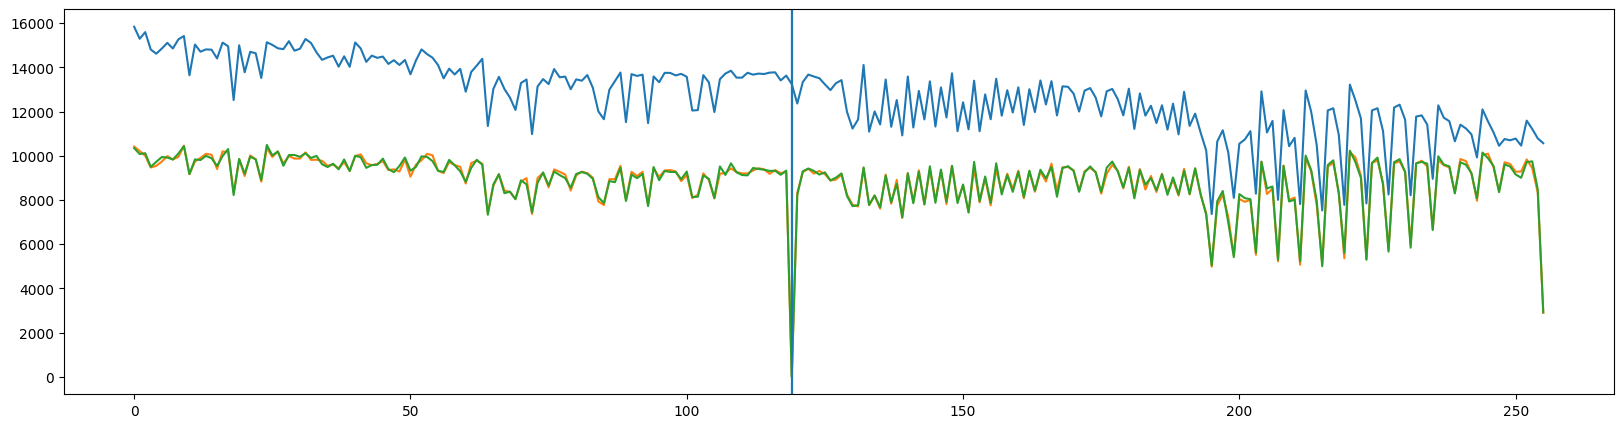

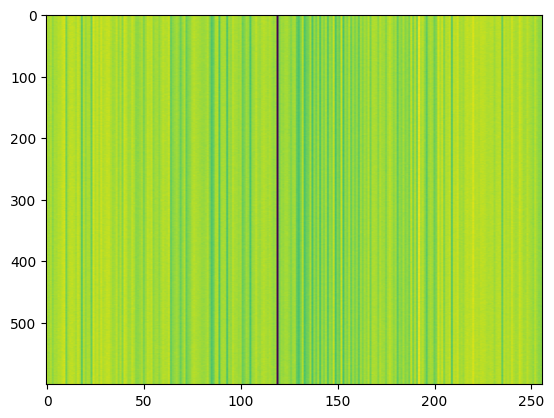

In [ ]:
cor_filepath = r"D:\Acq_gui\trash\ScanTask_002_10.0mmps_75kv_1.0ma_2.0mspf_sid610_sdd670_cali_.mat"
cor_pos, cor_data = load_mat_from_file(cor_filepath)
print(cor_pos.shape, cor_data.shape)

plt.imshow(cor_data.sum(axis=-1), aspect="auto")

(400, 4) (400, 256, 101)
(150, 256, 101)


C:\Users\ranch\AppData\Local\Temp\ipykernel_21368\2320587857.py:7: RuntimeWarning: divide by zero encountered in divide
  norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))
C:\Users\ranch\AppData\Local\Temp\ipykernel_21368\2320587857.py:7: RuntimeWarning: invalid value encountered in multiply
  norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))


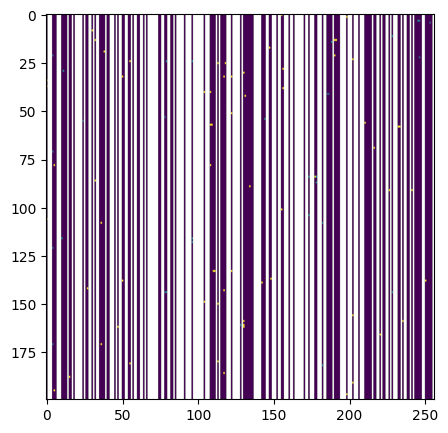

In [ ]:


norm_data = cor_data[50:200]
print(norm_data.shape)
norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))

fig = plt.figure(figsize=(5, 5))
plt.imshow(norm_cor_data[200:800,:], aspect='auto')
# sag_filepath = r"C:\Users\vplus\Documents\Projects\Acq_gui\ScanTask_600_100mmps_80kv_10ma_cali_10mspf_sid1000_cor.mat"

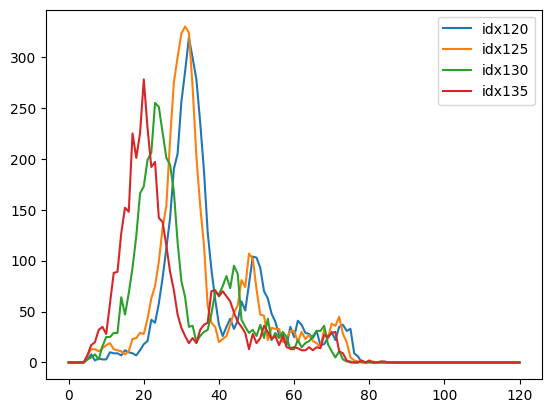

In [64]:
spectrum = cor_data.sum(axis=0)

spectrum2 = spectrum.T
spectrum2[:5, :] = 0

for i in range(120, 140, 5):
    _ = plt.plot(spectrum2[:, i], label=f"idx{i}")

plt.legend()

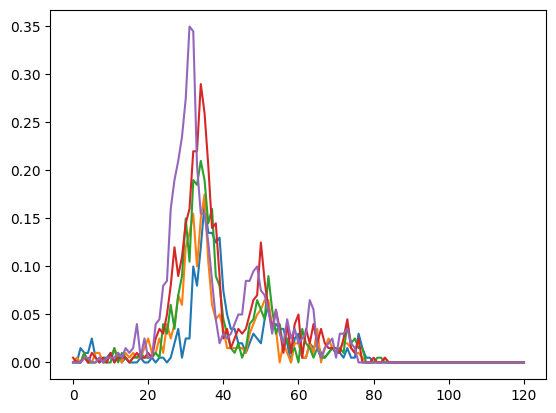

In [65]:
for cid in range(0,50,10):
    plt.plot(cor_data[0:200,cid,:].mean(axis=0))

In [6]:
import os
from tqdm import tqdm

base_dir = r"D:\Acq_gui\bei_acq"
all_pixel_arr = []
for filename in tqdm(os.listdir(base_dir)[:2000]):
    pos_arr, pix_arr = load_mat_from_file(os.path.join(base_dir, filename))
    all_pixel_arr.append(pix_arr)


100%|██████████| 2000/2000 [00:11<00:00, 179.23it/s]


In [7]:

all_pixel_arr2 = np.array(all_pixel_arr)

print(all_pixel_arr2.shape)

(2000, 50, 256, 101)


In [8]:

all_pixel_arr3 = np.vstack(all_pixel_arr)
print(all_pixel_arr3.shape)

(100000, 256, 101)


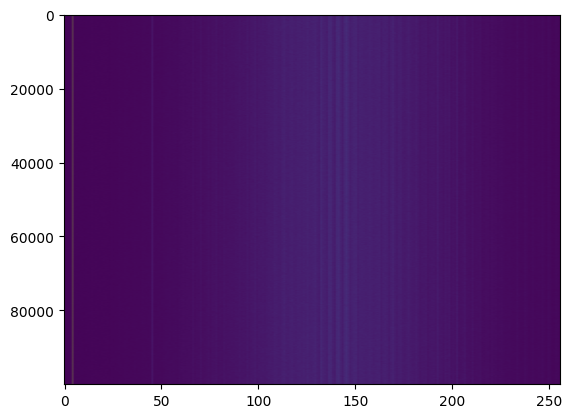

In [9]:

plt.imshow(all_pixel_arr3.sum(axis=2), aspect='auto')

In [10]:
tmp = all_pixel_arr3.sum(axis=0)[:, 10:]

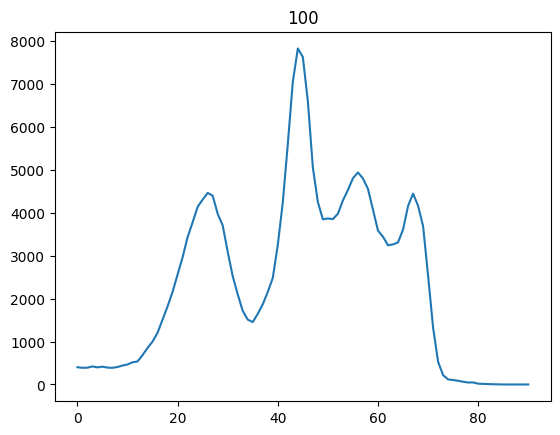

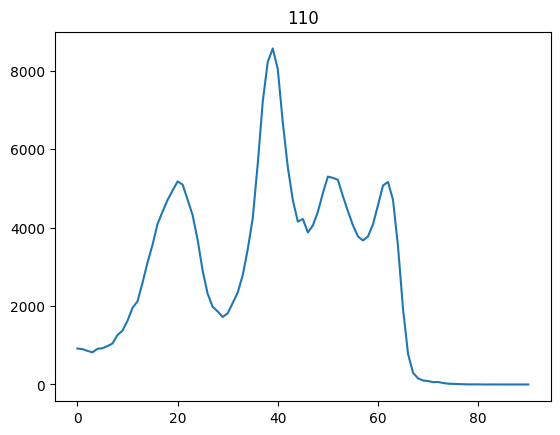

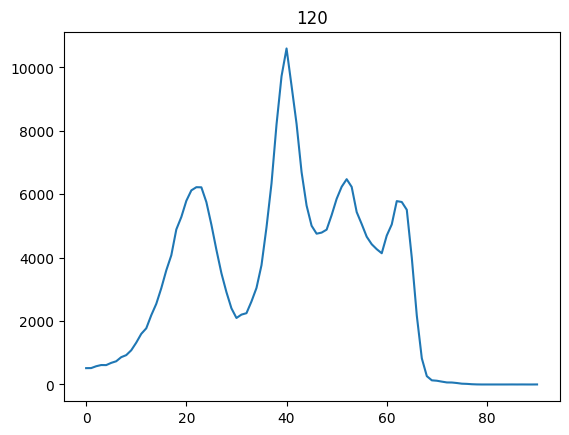

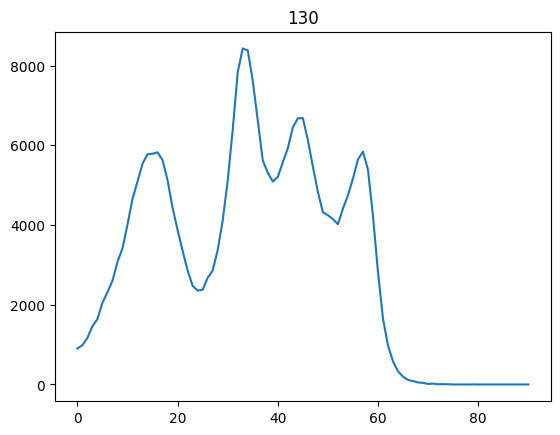

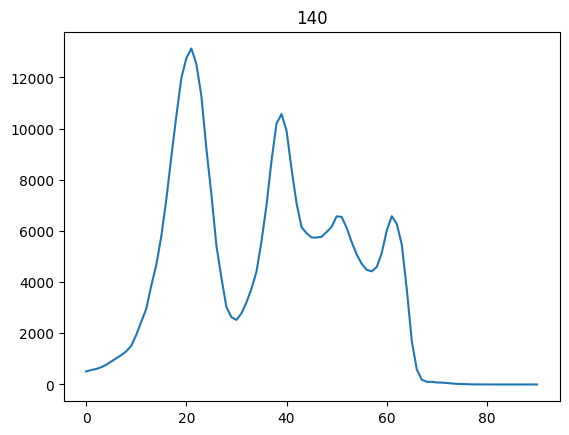

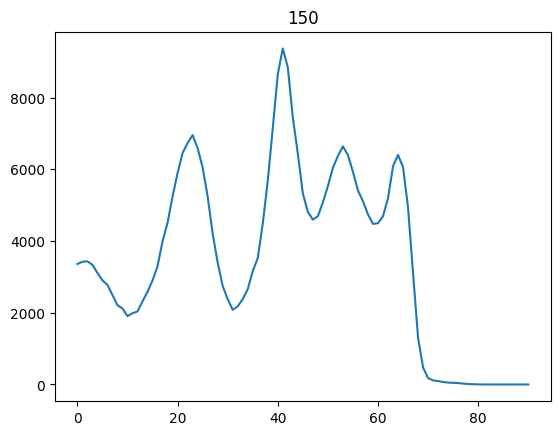

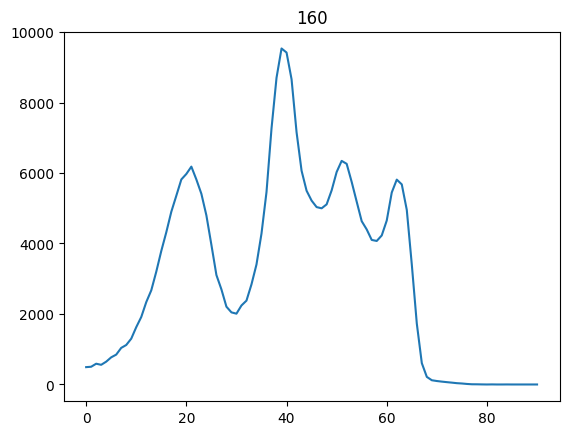

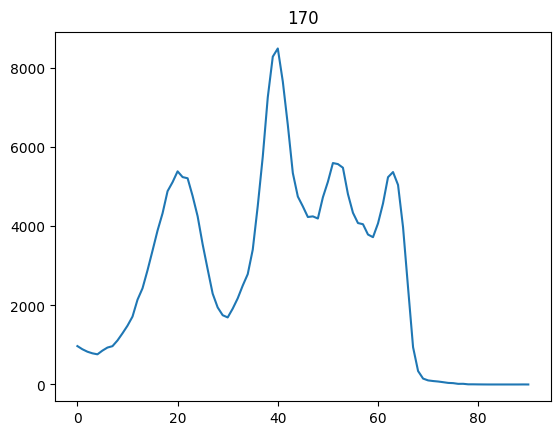

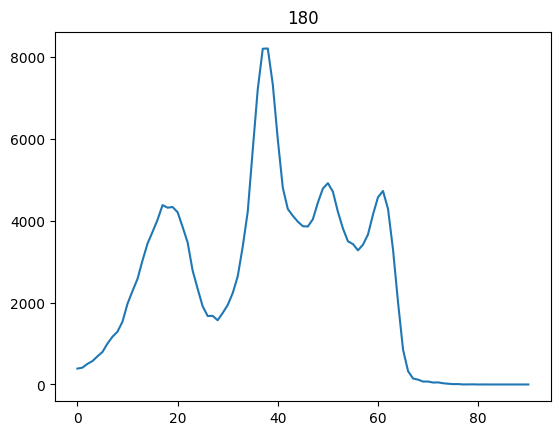

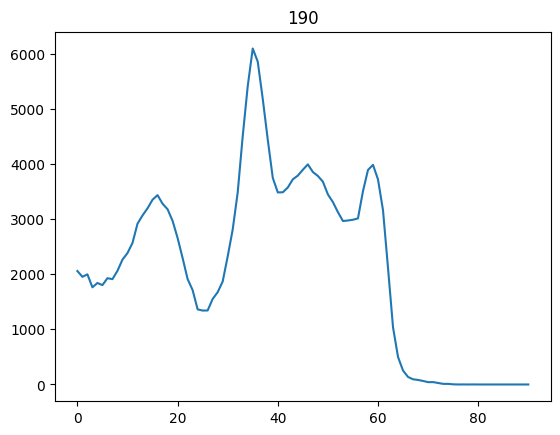

In [11]:
for i in range(100, 200, 10):
    _ = plt.plot(tmp[i].T)
    plt.title(i)
    plt.show()